In [14]:
import pickle 
import numpy as np

gt_path = "/home/lucas/repos/PointPillars/sparsepcgc_eval/kitti_infos_val.pkl"
restructed_path = "/home/lucas/repos/PointPillars/sparsepcgc_results/sparse_results_lossy_gpcc/results.pkl"
with open(gt_path, 'rb') as file:
        loaded_data = pickle.load(file)

with open(restructed_path, 'rb') as file:
        eval_data = pickle.load(file)
print(loaded_data[1]['annos'].keys())
print(eval_data.keys())
annos1 = eval_data[27]
print(annos1.keys())
print(annos1['location'])

dict_keys(['name', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y', 'difficulty', 'num_points_in_gt'])
dict_keys([1, 2, 4, 5, 6, 8, 15, 19, 20, 21, 23, 24, 25, 27, 28, 31, 33, 35, 37, 39, 40, 42, 47, 48, 50, 52, 53, 58, 59, 61, 62, 63, 65, 66, 76, 77, 78, 81, 89, 90, 93, 94, 98, 102, 104, 106, 107, 108, 116, 117, 118, 122, 124, 126, 128, 132, 134, 135, 137, 139, 140, 143, 147, 151, 152, 153, 156, 159, 161, 167, 168, 169, 170, 173, 174, 175, 181, 182, 183, 186, 187, 188, 190, 191, 192, 194, 195, 196, 197, 199, 201, 203, 204, 207, 211, 212, 213, 216, 218, 223, 224, 226, 229, 230, 231, 234, 235, 236, 237, 239, 242, 246, 247, 248, 249, 250, 251, 252, 260, 262, 263, 265, 266, 268, 269, 270, 272, 273, 278, 279, 281, 283, 284, 289, 290, 291, 293, 297, 301, 302, 305, 307, 308, 309, 311, 312, 314, 315, 319, 320, 321, 323, 324, 327, 328, 329, 332, 333, 335, 336, 340, 341, 343, 345, 346, 347, 350, 351, 352, 354, 355, 356, 357, 359, 360, 361, 362, 365, 366, 369, 37

In [15]:
def bbox3d2corners(bboxes):
    '''
    bboxes: shape=(n, 7)
    return: shape=(n, 8, 3)
           ^ z   x            6 ------ 5
           |   /             / |     / |
           |  /             2 -|---- 1 |   
    y      | /              |  |     | | 
    <------|o               | 7 -----| 4
                            |/   o   |/    
                            3 ------ 0 
    x: front, y: left, z: top
    '''
    centers, dims, angles = bboxes[:, :3], bboxes[:, 3:6], bboxes[:, 6]

    # 1.generate bbox corner coordinates, clockwise from minimal point
    bboxes_corners = np.array([[-0.5, -0.5, 0], [-0.5, -0.5, 1.0], [-0.5, 0.5, 1.0], [-0.5, 0.5, 0.0],
                               [0.5, -0.5, 0], [0.5, -0.5, 1.0], [0.5, 0.5, 1.0], [0.5, 0.5, 0.0]], 
                               dtype=np.float32)
    bboxes_corners = bboxes_corners[None, :, :] * dims[:, None, :] # (1, 8, 3) * (n, 1, 3) -> (n, 8, 3)

    # 2. rotate around z axis
    rot_sin, rot_cos = np.sin(angles), np.cos(angles)
    # in fact, -angle
    rot_mat = np.array([[rot_cos, rot_sin, np.zeros_like(rot_cos)],
                        [-rot_sin, rot_cos, np.zeros_like(rot_cos)],
                        [np.zeros_like(rot_cos), np.zeros_like(rot_cos), np.ones_like(rot_cos)]], 
                        dtype=np.float32) # (3, 3, n)
    rot_mat = np.transpose(rot_mat, (2, 1, 0)) # (n, 3, 3)
    bboxes_corners = bboxes_corners @ rot_mat # (n, 8, 3)

    # 3. translate to centers
    bboxes_corners += centers[:, None, :]
    return bboxes_corners

In [16]:

def bbox3d2corners(bboxes):
    '''
    bboxes: shape=(n, 7)
    return: shape=(n, 8, 3)
           ^ z   x            6 ------ 5
           |   /             / |     / |
           |  /             2 -|---- 1 |   
    y      | /              |  |     | | 
    <------|o               | 7 -----| 4
                            |/   o   |/    
                            3 ------ 0 
    x: front, y: left, z: top
    '''
    print(np.shape(bboxes))
    centers, dims, angles = bboxes[:, :3], bboxes[:, 3:6], bboxes[:, 6]

    # 1.generate bbox corner coordinates, clockwise from minimal point
    bboxes_corners = np.array([[-0.5, -0.5, 0], [-0.5, -0.5, 1.0], [-0.5, 0.5, 1.0], [-0.5, 0.5, 0.0],
                               [0.5, -0.5, 0], [0.5, -0.5, 1.0], [0.5, 0.5, 1.0], [0.5, 0.5, 0.0]], 
                               dtype=np.float32)
    bboxes_corners = bboxes_corners[None, :, :] * dims[:, None, :] # (1, 8, 3) * (n, 1, 3) -> (n, 8, 3)

    # 2. rotate around z axis
    rot_sin, rot_cos = np.sin(angles), np.cos(angles)
    # in fact, -angle
    rot_mat = np.array([[rot_cos, rot_sin, np.zeros_like(rot_cos)],
                        [-rot_sin, rot_cos, np.zeros_like(rot_cos)],
                        [np.zeros_like(rot_cos), np.zeros_like(rot_cos), np.ones_like(rot_cos)]], 
                        dtype=np.float32) # (3, 3, n)
    rot_mat = np.transpose(rot_mat, (2, 1, 0)) # (n, 3, 3)
    bboxes_corners = bboxes_corners @ rot_mat # (n, 8, 3)

    # 3. translate to centers
    bboxes_corners += centers[:, None, :]
    return bboxes_corners

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D

def draw_pointcloud_with_boxes(bin_path,
                               boxes_corners_gt,

                               boxes_corners_pred=None,
                               boxes_names_gt=None,
                               boxes_names_pred=None,
                               class_filter=None,
                               mode="default",
                               show=True,
                               other_color='tab:blue',
                               pred_color='tab:red'):
    """
    Draw a KITTI-format point cloud and overlay up to three sets of 3D bounding boxes on a single canvas
    with two subplots: a 3D view (left) and a bird's-eye view (BEV, right).

    New parameters
    --------------
    boxes_names_gt, boxes_names_other, boxes_names_pred : array-like or None
        Optional arrays of same length as corresponding corners arrays containing class labels
        (e.g. 'Car', 'Pedestrian', 'Cyclist') or containers of labels. If provided, they are used
        for optional class filtering.
    class_filter : str or None
        If set to a class name (e.g. 'Pedestrian'), only boxes that include that class in their
        corresponding name entry will be drawn.

    Other parameters unchanged.
    """
    # helper to turn candidate names to a mask matching corners
    def _filter_by_class(corners, names, cls):
        if cls is None or corners is None:
            return corners
        if names is None:
            # no names provided -> assume keep all
            return corners
        # try to coerce names to a list-like with same length as corners
        try:
            names_arr = list(names)
        except Exception:
            # can't iterate names -> keep all
            return corners
        if len(names_arr) != corners.shape[0]:
            # length mismatch; can't reliably filter -> keep all
            return corners
        mask = []
        for n in names_arr:
            if n is None:
                mask.append(False)
                continue
            if isinstance(n, str):
                mask.append(n == cls)
            elif isinstance(n, (list, tuple, set, np.ndarray)):
                try:
                    mask.append(cls in n)
                except Exception:
                    mask.append(False)
            else:
                # fallback to string containment
                try:
                    mask.append(cls in str(n))
                except Exception:
                    mask.append(False)
        mask = np.array(mask, dtype=bool)
        return corners[mask]

    # Load point cloud
    points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

    # Print simple extents for quick debugging
    if points.size == 0:
        print("Point cloud empty:", bin_path)
    else:
        xmin, xmax = points[:, 0].min(), points[:, 0].max()
        ymin, ymax = points[:, 1].min(), points[:, 1].max()
        zmin, zmax = points[:, 2].min(), points[:, 2].max()
        print(f"{bin_path} -> x: min={xmin:.3f}, max={xmax:.3f}; y: min={ymin:.3f}, max={ymax:.3f}; z: min={zmin:.3f}, max={zmax:.3f}")

    fig = plt.figure(figsize=(14, 7))
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    axbev = fig.add_subplot(1, 2, 2)

    ax3d.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.1, c='gray', alpha=0.5)
    axbev.scatter(points[:, 0], points[:, 1], s=0.5, c='gray', alpha=0.4)

    def _as_corners_array(boxes):
        if boxes is None:
            return np.zeros((0, 8, 3), dtype=np.float32)
        arr = np.asarray(boxes)
        if arr.ndim == 3 and arr.shape[1:] == (8, 3):
            return arr
        # assume list-like of (8,3)
        return np.stack(list(boxes), axis=0) if len(boxes) > 0 else np.zeros((0, 8, 3), dtype=np.float32)

    gt = _as_corners_array(boxes_corners_gt)
    other = _as_corners_array(boxes_corners_other)
    pred = _as_corners_array(boxes_corners_pred)

    # Apply class filtering if requested
    if class_filter is not None:
        gt = _filter_by_class(gt, boxes_names_gt, class_filter)
        other = _filter_by_class(other, boxes_names_other, class_filter)
        pred = _filter_by_class(pred, boxes_names_pred, class_filter)

    def draw_box_3d(ax, corners, color='r', linewidth=1.5):
        edges = [
            [0,1],[1,2],[2,3],[3,0],  # bottom
            [4,5],[5,6],[6,7],[7,4],  # top
            [0,4],[1,5],[2,6],[3,7]   # sides
        ]
        for e in edges:
            p0 = corners[e[0]]
            p1 = corners[e[1]]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=linewidth)

    def draw_box_bev(ax, corners, color='r', linewidth=1.5):
        # Use bottom face indices 0-3 for BEV
        xy = corners[:, :2]
        edges = [[0,1],[1,2],[2,3],[3,0]]
        for e in edges:
            ax.plot([xy[e[0], 0], xy[e[1], 0]], [xy[e[0], 1], xy[e[1], 1]], color=color, linewidth=linewidth)

    # Draw ground-truth boxes (green)
    for corners in gt:
        draw_box_3d(ax3d, corners, color='tab:green', linewidth=1.8)
        draw_box_bev(axbev, corners, color='tab:green', linewidth=1.8)

    # Draw "other" boxes (custom color)
    for corners in other:
        draw_box_3d(ax3d, corners, color=other_color, linewidth=1.6)
        draw_box_bev(axbev, corners, color=other_color, linewidth=1.6)

    # Draw predicted boxes (pred_color)
    for corners in pred:
        draw_box_3d(ax3d, corners, color=pred_color, linewidth=1.2)
        draw_box_bev(axbev, corners, color=pred_color, linewidth=1.2)

    # Legend (proxy artists)
    legend_elems = [Line2D([0], [0], color='tab:green', lw=2, label='Ground Truth')]
    if other.shape[0] > 0:
        legend_elems.append(Line2D([0], [0], color=other_color, lw=2, label='Other'))
    if pred.shape[0] > 0:
        legend_elems.append(Line2D([0], [0], color=pred_color, lw=2, label='Predicted'))
    if class_filter is not None:
        legend_title = f"Filtered: {class_filter}"
        axbev.legend(handles=legend_elems, title=legend_title)
    else:
        axbev.legend(handles=legend_elems)

    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('3D View')

    axbev.set_xlabel('X')
    axbev.set_ylabel('Y')
    axbev.set_title('Bird\'s-Eye View (BEV)')
    axbev.axis('equal')

    # Tweak views
    if mode == 'bev':
        ax3d.view_init(elev=90, azim=-90)
    else:
        ax3d.view_init(elev=20, azim=-45)

    # Optional: set BEV limits to point cloud extents with small margin
    try:
        xmin, ymin = points[:, 0].min(), points[:, 1].min()
        xmax, ymax = points[:, 0].max(), points[:, 1].max()
        dx, dy = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
        axbev.set_xlim(xmin - dx, xmax + dx)
        axbev.set_ylim(ymin - dy, ymax + dy)
    except Exception:
        pass

    plt.tight_layout()
    if show:
        plt.show()
    return fig, (ax3d, axbev)


In [18]:
def points_camera2lidar(points, tr_velo_to_cam, r0_rect):
    '''
    points: shape=(N, 8, 3) 
    tr_velo_to_cam: shape=(4, 4)
    r0_rect: shape=(4, 4)
    return: shape=(N, 8, 3)
    '''
    extended_xyz = np.pad(points, ((0, 0), (0, 0), (0, 1)), 'constant', constant_values=1.0)
    rt_mat = np.linalg.inv(r0_rect @ tr_velo_to_cam)
    xyz = extended_xyz @ rt_mat.T
    return xyz[..., :3]

(2, 7)
(7, 7)
/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000089.bin -> x: min=3.913, max=79.914; y: min=-7.178, max=6.229; z: min=-2.279, max=2.912


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


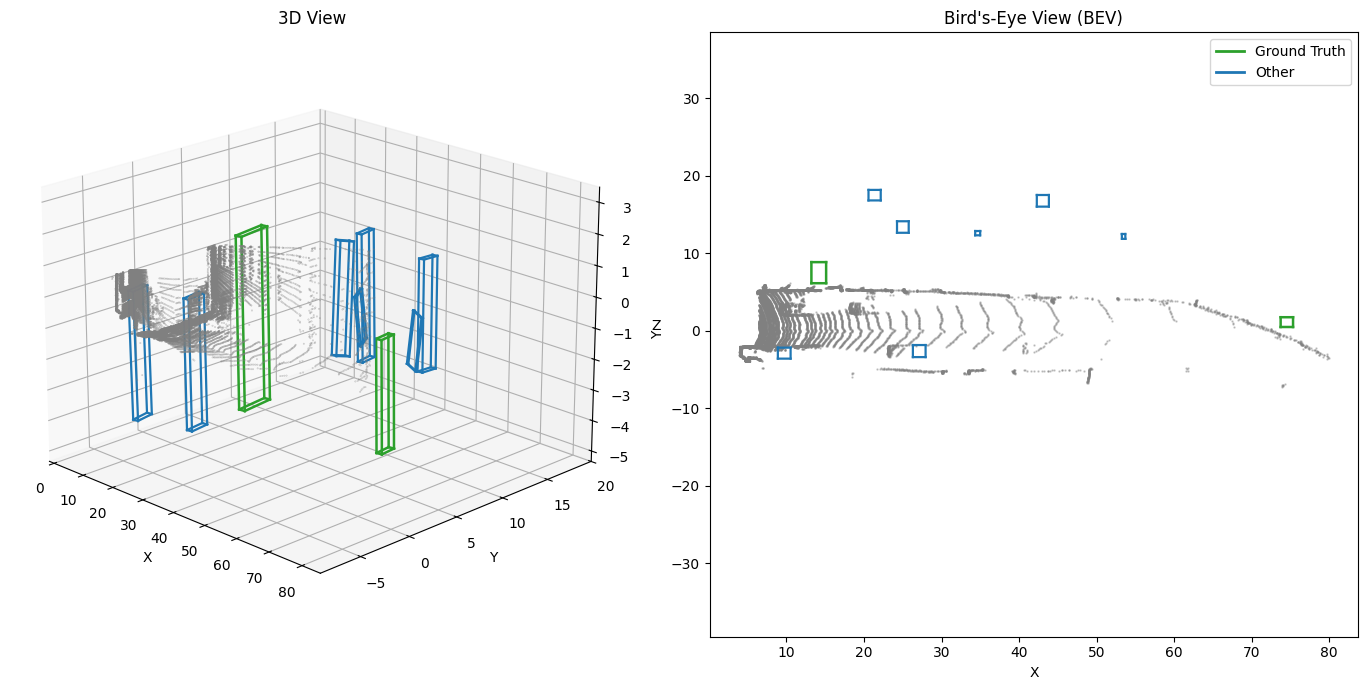

(<Figure size 1400x700 with 2 Axes>,
 (<Axes3D: title={'center': '3D View'}, xlabel='X', ylabel='Y', zlabel='Z'>,
  <Axes: title={'center': "Bird's-Eye View (BEV)"}, xlabel='X', ylabel='Y'>))

In [19]:
import numpy as np

pcd_limit_range = np.array([0, -40, -3, 70.4, 40, 0.0], dtype=np.float32)
# Extract annotation arrays
idx = 27
annos = loaded_data[idx]['annos']
annos1 = eval_data[idx]

locations = annos['location']
dimensions = annos['dimensions']
rotations_y = annos['rotation_y']

locations1 = annos1['location']
dimensions1 = annos1['dimensions']
rotations_y1 = annos1['rotation_y']

calib = loaded_data[idx]['calib']
r0_rect = calib['R0_rect']
tr_velo_to_cam = calib['Tr_velo_to_cam']

# Filter out invalid boxes (e.g., 'DontCare' or negative dimensions)
valid_mask = (annos['name'] != 'DontCare') & (dimensions[:, 0] > 0) & (dimensions[:, 1] > 0) & (dimensions[:, 2] > 0)
valid_mask1 = (annos1['name'] != 'DontCare') & (dimensions1[:, 0] > 0) & (dimensions1[:, 1] > 0) & (dimensions1[:, 2] > 0)

locations_valid = locations[valid_mask]
dimensions_valid = dimensions[valid_mask]
rotations_y_valid = rotations_y[valid_mask]
locations1_valid = locations1[valid_mask1]
dimensions1_valid = dimensions1[valid_mask1]
rotations_y1_valid = rotations_y1[valid_mask1]

# Compute corners for each valid box
# boxes_corners = [compute_box_corners(loc, dim, ry) for loc, dim, ry in zip(locations_valid, dimensions_valid, rotations_y_valid)]
bboxes = np.concatenate([locations_valid, dimensions_valid, rotations_y_valid[:, None]], axis=1)  # shape: (N, 7)
bboxes1 = np.concatenate([locations1_valid, dimensions1_valid, rotations_y1_valid[:, None]], axis=1)  # shape: (N, 7)

boxes_corners = bbox3d2corners(bboxes)
bboxes_corners2 = bbox3d2corners(bboxes1)
boxes_corners_in_lidar = points_camera2lidar(points=boxes_corners,
                                             r0_rect=r0_rect,
                                             tr_velo_to_cam=tr_velo_to_cam)
boxes_corners2_in_lidar = points_camera2lidar(points=bboxes_corners2,
                                             r0_rect=r0_rect,
                                             tr_velo_to_cam=tr_velo_to_cam)
# print(boxes_corners)
# print(boxes_corners2)
# Draw on the point cloud
# boxes_corners2 = keep_bbox_from_lidar_range_strict(boxes_corners2, pcd_limit_range)
draw_pointcloud_with_boxes('/home/lucas/repos/PointPillars/kitti/training/velodyne_reduced/000089.bin', boxes_corners_in_lidar, boxes_corners2_in_lidar, mode='default', show=True)

In [20]:
import numpy as np
def keep_bbox_from_lidar_range_strict(lidar_bboxes_or_corners, pcd_limit_range, return_mask=False):
    """
    Keep boxes if any of their 8 corners lies inside the axis-aligned pcd_limit_range.

    Accepts either:
      - lidar_bboxes: (N,7) array where each row is [x, y, z, h, w, l, ry]
      - corners: (N,8,3) array of box corners

    pcd_limit_range: [xmin, ymin, zmin, xmax, ymax, zmax]

    Returns
    -------
    kept_corners : ndarray shape (M, 8, 3)
        Corners of boxes that were kept. M may be 0.
    (optional) mask : ndarray shape (N,) bool
        If return_mask is True, also returns the boolean mask aligned with the input order.
    """
    arr = np.asarray(lidar_bboxes_or_corners)
    if arr.size == 0:
        empty = np.zeros((0, 8, 3), dtype=np.float32)
        if return_mask:
            return empty, np.zeros((0,), dtype=bool)
        return empty


    corners = arr 
    mins = np.array(pcd_limit_range[:3], dtype=corners.dtype)
    maxs = np.array(pcd_limit_range[3:], dtype=corners.dtype)

    # corners_in_range: (N, 8, 3) boolean where True means coordinate within [min, max]
    corners_in_range = np.logical_and(corners >= mins[None, None, :], corners <= maxs[None, None, :])

    # corner_fully_inside: (N, 8) True if that corner is fully inside the AABB
    corner_fully_inside = np.all(corners_in_range, axis=2)

    # keep box if any of its 8 corners is inside the AABB
    keep_mask = np.any(corner_fully_inside, axis=1)

    kept_corners = corners[keep_mask]
    if return_mask:
        return kept_corners, keep_mask
    return kept_corners